In [145]:
"""Paper-oriented analysis of the modeling artifacts."""

'Paper-oriented analysis of the modeling artifacts.'

# Modeling Results for the Paper Revision

This notebook consolidates the main results and turns them into
manuscript-ready figures, tables, and short interpretation blocks. The
emphasis is on reviewer-facing evidence:

- baseline predictive accuracy for SOH and RUL,
- empirical behavior of the conformal uncertainty intervals,
- robustness under leave-one-protocol-out (LOPO) validation,
- compact feature-subset selection via the top-k sweep,
- qualitative interpretation of the most influential statistical features.

The notebook does not attempt to answer every reviewer comment. In
particular, temperature ablations, smoothing-window sensitivity, and
charge-only versus full-cycle comparisons require additional experiments and
are therefore treated here only as discussion points when the corresponding
artifacts are not available.

In [146]:
import json
from pathlib import Path

from IPython.display import Markdown, display
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import r2_score, root_mean_squared_error

from severson_features_soh_rul.utils.plots import create_figure


def resolve_repo_root() -> Path:
    """Resolve repository root both in notebooks and script execution."""
    if "__file__" in globals():
        return Path(__file__).resolve().parents[2]
    return Path().absolute().parent.parent


REPO_ROOT = resolve_repo_root()
plt.style.use(REPO_ROOT / ".matplotlibrc")
SAVE_TO_OVERLEAF = True
OVERLEAF_DIR = REPO_ROOT / "paper" / "overleaf_project"


def save_figure(fig: plt.Figure, filename: str, save_pdf=True) -> None:
    """Save a figure into the Overleaf project without overwriting files."""
    output_path = OVERLEAF_DIR / filename
    if not SAVE_TO_OVERLEAF:
        print(f"SAVE_TO_OVERLEAF=False -> skipped {output_path.name}")
        return
    if output_path.exists():
        print(f"Skipping existing file: {output_path.name}")
        return
    if save_pdf:
        fig.savefig(
            f"{output_path}.pdf",
            dpi=500,
            bbox_inches="tight",
            format="pdf",
        )
    else:
        fig.savefig(
            f"{output_path}.png",
            dpi=500,
            bbox_inches="tight",
        )
    print(f"Saved {output_path}")

## Data Loading and Shared Helpers

The analysis below is fully artifact-driven. Each target is represented by
one metadata-resolved artifact directory containing the optimization history,
the final test predictions, the permutation-importance outputs, the top-k
sweep, and the protocol LOPO evaluation.

In [147]:
BASE_PATH = REPO_ROOT
RESULTS_ROOT = BASE_PATH / "results_refactored" / "modeling"
NOMINAL_CONFIDENCE_LEVEL = 0.95

ARTIFACTS = {
    "SOH": RESULTS_ROOT
    / (
        "target-soh__feature_hash-"
        "d3c068bcf5e7a4c6ed2306b1952bf61d5ebe1e1691881fc154114f0df9bdf07c__"
        "split_seed-42__model_name-extratrees_quantile__"
        "weighting_strategy-none__rk-d5cd9b0abb"
    ),
    "RUL": RESULTS_ROOT
    / (
        "target-rul__feature_hash-"
        "d3c068bcf5e7a4c6ed2306b1952bf61d5ebe1e1691881fc154114f0df9bdf07c__"
        "split_seed-42__model_name-extratrees_quantile__"
        "weighting_strategy-none__rk-3df7df7b6c"
    ),
}


def add_prediction_columns(pred_df: pd.DataFrame) -> pd.DataFrame:
    """Return prediction DataFrame enriched with error/coverage columns."""
    enriched = pred_df.copy()
    enriched["interval_width"] = enriched["y_pred_hi"] - enriched["y_pred_lo"]
    enriched["abs_error"] = (enriched["y_true"] - enriched["y_pred"]).abs()
    enriched["signed_error"] = enriched["y_pred"] - enriched["y_true"]
    enriched["covered"] = (enriched["y_true"] >= enriched["y_pred_lo"]) & (
        enriched["y_true"] <= enriched["y_pred_hi"]
    )
    return enriched


def load_target_bundle(artifacts_dir: Path) -> dict[str, object]:
    """Load the artifact bundle associated with one target."""
    optimize_history = pd.read_csv(
        artifacts_dir / "optimize" / "cv_trials.csv"
    )
    predictions = add_prediction_columns(
        pd.read_parquet(artifacts_dir / "predict" / "predictions_test.parquet")
    )
    ranking = pd.read_csv(artifacts_dir / "rank" / "ranking_composite.csv")
    topk_sweep = pd.read_csv(
        artifacts_dir / "topk_sweep" / "topk_sweep_cv.csv"
    )
    lopo_predictions = add_prediction_columns(
        pd.read_parquet(
            artifacts_dir
            / "robustness_protocol_lopo"
            / "predictions_protocol_lopo.parquet"
        )
    )
    with open(artifacts_dir / "topk_sweep" / "topk_selection.json") as handle:
        topk_selection = json.load(handle)

    return {
        "optimize_history": optimize_history,
        "predictions": predictions,
        "ranking": ranking,
        "topk_sweep": topk_sweep,
        "topk_selection": topk_selection,
        "lopo_predictions": lopo_predictions,
    }


def compute_global_summary(
    target: str, pred_df: pd.DataFrame
) -> dict[str, object]:
    """Compute manuscript-level summary metrics for one prediction artifact."""
    return {
        "target": target,
        "n_cells": int(pred_df["cell"].nunique()),
        "n_samples": int(pred_df.shape[0]),
        "rmse": root_mean_squared_error(pred_df["y_true"], pred_df["y_pred"]),
        "r2": r2_score(pred_df["y_true"], pred_df["y_pred"]),
        "empirical_coverage": float(pred_df["covered"].mean()),
        "mean_interval_width": float(pred_df["interval_width"].mean()),
        "median_interval_width": float(pred_df["interval_width"].median()),
        "width_error_corr": float(
            pred_df["interval_width"].corr(pred_df["abs_error"])
        ),
    }


def compute_cell_metrics(target: str, pred_df: pd.DataFrame) -> pd.DataFrame:
    """Compute per-cell predictive and uncertainty metrics."""
    rows: list[dict[str, object]] = []
    for cell, chunk in pred_df.groupby("cell", sort=False):
        rows.append(
            {
                "target": target,
                "cell": str(cell),
                "n_samples": int(chunk.shape[0]),
                "rmse": root_mean_squared_error(
                    chunk["y_true"], chunk["y_pred"]
                ),
                "r2": r2_score(chunk["y_true"], chunk["y_pred"]),
                "coverage": float(chunk["covered"].mean()),
                "mean_interval_width": float(chunk["interval_width"].mean()),
                "median_interval_width": float(
                    chunk["interval_width"].median()
                ),
                "life_proxy": float(chunk["y_true"].max()),
            }
        )
    return (
        pd.DataFrame(rows)
        .sort_values("rmse", ascending=True)
        .reset_index(drop=True)
    )


def compute_protocol_metrics(
    target: str, pred_df: pd.DataFrame
) -> pd.DataFrame:
    """Aggregate strict protocol-LOPO predictions by held-out protocol."""
    rows: list[dict[str, object]] = []
    for protocol, chunk in pred_df.groupby("held_out_protocol", sort=False):
        rows.append(
            {
                "target": target,
                "protocol": str(protocol).replace("-newstructure", ""),
                "n_cells": int(chunk["cell"].nunique()),
                "n_samples": int(chunk.shape[0]),
                "rmse": root_mean_squared_error(
                    chunk["y_true"], chunk["y_pred"]
                ),
                "coverage": float(chunk["covered"].mean()),
                "mean_interval_width": float(chunk["interval_width"].mean()),
            }
        )
    return (
        pd.DataFrame(rows)
        .sort_values("rmse", ascending=True)
        .reset_index(drop=True)
    )


def build_best_params_table(optimize_history: pd.DataFrame) -> pd.DataFrame:
    """Extract the best hyperparameter row from the optimization history."""
    best_trial = optimize_history.loc[optimize_history["objective"].idxmin()]
    parameter_cols = [
        "n_estimators",
        "max_depth",
        "min_samples_split",
        "min_samples_leaf",
        "max_features",
        "criterion",
        "rmse_val_mean",
        "overfit_gap_mean",
        "objective",
    ]
    return best_trial[parameter_cols].to_frame().T.reset_index(drop=True)


def build_feature_interpretation_table(
    ranking_df: pd.DataFrame,
    top_n: int = 8,
) -> pd.DataFrame:
    """Attach short physical interpretations to the highest-ranked features."""
    interpretation_map = {
        "V_entropy": (
            "Voltage-profile irregularity; a proxy for waveform complexity and "
            "growing heterogeneity/polarization."
        ),
        "V_std": (
            "Voltage spread within the diagnostic cycle; consistent with larger "
            "intra-cycle polarization excursions."
        ),
        "V_median": (
            "Central tendency of the voltage trace; sensitive to systematic "
            "shifts in operating window and overpotential."
        ),
        "V_iqr": (
            "Robust voltage dispersion; captures broadening of the voltage "
            "response while being less sensitive to isolated outliers."
        ),
        "V_kurtosis": (
            "Tail-heaviness of the voltage distribution; can increase when the "
            "trajectory contains more localized transients."
        ),
        "I_mean": (
            "Average current level seen by the model under a given protocol, "
            "informative of stress severity and protocol identity."
        ),
        "I_std": (
            "Current variability during the cycle; reflects how strongly the "
            "applied current departs from a flat profile."
        ),
        "I_iqr": (
            "Robust current spread; helps distinguish protocol regimes and "
            "control variability."
        ),
        "I_kurtosis": (
            "Current transients and tail behavior; useful when localized high-C "
            "segments differentiate degradation trajectories."
        ),
        "I_median": (
            "Central current tendency; another compact summary of protocol "
            "severity."
        ),
        "T_std": (
            "Temperature variability; can reflect uneven thermal response even "
            "when absolute temperature is noisy."
        ),
        "T_mean": (
            "Average thermal level during the diagnostic cycle; linked to heat "
            "generation and cooling balance."
        ),
    }
    top_ranked = ranking_df.head(top_n).copy()
    top_ranked["mechanistic_interpretation"] = (
        top_ranked["feature"]
        .map(interpretation_map)
        .fillna(
            "Statistical descriptor retained by the ranking heuristic; likely "
            "acting as a compact summary of the cycle waveform."
        )
    )
    return top_ranked[
        ["feature", "composite_score", "mechanistic_interpretation"]
    ].reset_index(drop=True)


def select_representative_cells(cell_metrics: pd.DataFrame) -> list[str]:
    """Return worst, median, and best cells by RMSE."""
    ordered = cell_metrics.sort_values("rmse", ascending=True).reset_index(
        drop=True
    )
    return [
        str(ordered.iloc[0]["cell"]),
        str(ordered.iloc[len(ordered) // 2]["cell"]),
        str(ordered.iloc[-1]["cell"]),
    ]


def format_feature_subset(features: list[str]) -> str:
    """Format selected features for manuscript display."""
    return ", ".join(str(feature) for feature in features)


def add_panel_labels(axes: object, posx=-0.1, posy=1.1) -> None:
    """Add (a), (b), ... panel labels and disable subplot grids."""
    labels = [f"({chr(ord('a') + idx)})" for idx in range(26)]
    flat_axes = np.ravel(axes) if hasattr(axes, "__len__") else [axes]
    for idx, axis in enumerate(flat_axes):
        axis.text(
            posx,
            posy,
            labels[idx],
            transform=axis.transAxes,
            va="top",
            ha="left",
            fontweight="bold",
        )
        axis.grid(False)


TARGET_BUNDLES = {
    target: load_target_bundle(path) for target, path in ARTIFACTS.items()
}
GLOBAL_SUMMARY = pd.DataFrame(
    [
        compute_global_summary(target, bundle["predictions"])
        for target, bundle in TARGET_BUNDLES.items()
    ]
)
CELL_METRICS = {
    target: compute_cell_metrics(target, bundle["predictions"])
    for target, bundle in TARGET_BUNDLES.items()
}
PROTOCOL_METRICS = {
    target: compute_protocol_metrics(target, bundle["lopo_predictions"])
    for target, bundle in TARGET_BUNDLES.items()
}

## Manuscript Table 1: Overall Test-Set Performance and Uncertainty

**Methodology.** Predictions are evaluated on the held-out test cells
produced by the pipeline split. In addition to the standard point metrics
(RMSE and $R^2$), this table reports the empirical coverage of the
conformalized intervals and their characteristic width. The correlation
between interval width and absolute error is included as a compact diagnostic
of whether the uncertainty estimator is informative rather than merely wide.

In [148]:
overall_results_table = GLOBAL_SUMMARY.copy()
overall_results_table["rmse"] = overall_results_table["rmse"].map(
    "{:.3f}".format
)
overall_results_table["r2"] = overall_results_table["r2"].map("{:.3f}".format)
overall_results_table["empirical_coverage"] = overall_results_table[
    "empirical_coverage"
].map("{:.3f}".format)
overall_results_table["mean_interval_width"] = overall_results_table[
    "mean_interval_width"
].map("{:.2f}".format)
overall_results_table["median_interval_width"] = overall_results_table[
    "median_interval_width"
].map("{:.2f}".format)
overall_results_table["width_error_corr"] = overall_results_table[
    "width_error_corr"
].map("{:.3f}".format)
display(overall_results_table)

,target,n_cells,n_samples,rmse,r2,empirical_coverage,mean_interval_width,median_interval_width,width_error_corr
0,SOH,25,20184,1.309,0.911,0.941,5.21,4.57,0.531
1,RUL,25,20184,198.867,0.750,0.922,625.89,581.30,0.246


In [149]:
for _, row in GLOBAL_SUMMARY.iterrows():
    print(
        (
            f"{row['target']}: RMSE={row['rmse']:.3f}, R2={row['r2']:.3f}, "
            f"empirical coverage={row['empirical_coverage']:.3f} versus the "
            f"nominal {NOMINAL_CONFIDENCE_LEVEL:.0%} target, mean interval "
            f"width={row['mean_interval_width']:.2f}, width-error correlation="
            f"{row['width_error_corr']:.3f}."
        )
    )

SOH: RMSE=1.309, R2=0.911, empirical coverage=0.941 versus the nominal 95% target, mean interval width=5.21, width-error correlation=0.531.
RUL: RMSE=198.867, R2=0.750, empirical coverage=0.922 versus the nominal 95% target, mean interval width=625.89, width-error correlation=0.246.


The main paper-level message from Table 1 is that the proposed workflow
achieves strong point accuracy on both targets while retaining empirical
interval coverage reasonably close to the nominal 95% level. The positive
width-error correlations indicate that the sample-wise uncertainty estimates
are not arbitrary: intervals tend to widen on harder predictions, especially
for SOH where the relationship is more pronounced.

## Optimization Diagnostics

**Methodology.** The optimization stage uses grouped cross-validation over
the training cells only. Each trial is scored by validation RMSE plus an
explicit penalty on the train-to-validation generalization gap. The plots
below make that trade-off visible by showing where the selected trial sits in
the accuracy-versus-gap plane.

Saved /Users/clarafarias/code/severson_features_soh_rul/paper/overleaf_project/results_optimization_diagnostics


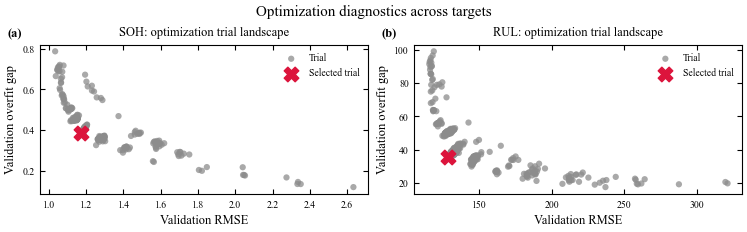

In [150]:
fig, axes = create_figure(
    layout_type="double",
    nrows=1,
    ncols=2,
)
fig.suptitle("Optimization diagnostics across targets")
for axis, (target, bundle) in zip(np.ravel(axes), TARGET_BUNDLES.items()):
    history = bundle["optimize_history"]
    best_trial = history.loc[history["objective"].idxmin()]
    axis.scatter(
        history["rmse_val_mean"],
        history["overfit_gap_mean"],
        color="0.55",
        alpha=0.75,
        edgecolors="none",
        label="Trial",
    )
    axis.scatter(
        [best_trial["rmse_val_mean"]],
        [best_trial["overfit_gap_mean"]],
        color="crimson",
        marker="X",
        s=110,
        label="Selected trial",
        zorder=5,
    )
    axis.set_title(f"{target}: optimization trial landscape")
    axis.set_xlabel("Validation RMSE")
    axis.set_ylabel("Validation overfit gap")
    axis.legend(loc="upper right")
add_panel_labels(axes)
save_figure(fig, "results_optimization_diagnostics")
plt.show()

In [151]:
best_params_tables = []
for target, bundle in TARGET_BUNDLES.items():
    best_params = build_best_params_table(bundle["optimize_history"])
    best_params.insert(0, "target", target)
    best_params_tables.append(best_params)
best_params_table = pd.concat(best_params_tables, ignore_index=True)
display(best_params_table)

,target,n_estimators,max_depth,min_samples_split,min_samples_leaf,max_features,criterion,rmse_val_mean,overfit_gap_mean,objective
0,SOH,115,9,5,10,NaN,squared_error,1.172028,0.385453,1.557481
1,RUL,85,8,16,1,NaN,squared_error,128.40217,35.745593,164.147764


The selected SOH and RUL configurations occupy low-error regions without
collapsing into the largest validation gaps, supporting the claim that the
objective is trading accuracy and generalization rather than only fitting the
easiest folds. This directly helps address the reviewer concern about
optimization stability and generalization.

## Predictive Fidelity on Held-Out Cells

**Methodology.** Instead of showing all 25 test cells at once, the notebook
highlights representative cases: the worst, median, and best cell according
to per-cell RMSE. This gives a compact picture of error modes while remaining
readable in a manuscript. The shaded bands correspond to the calibrated
prediction intervals used by the model.

Saved /Users/clarafarias/code/severson_features_soh_rul/paper/overleaf_project/results_representative_cells_soh


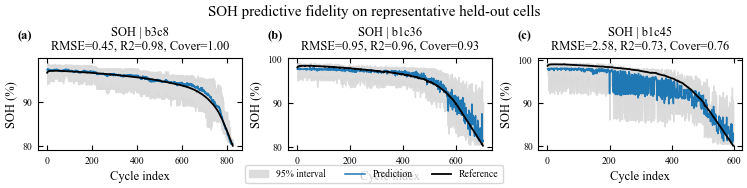

Saved /Users/clarafarias/code/severson_features_soh_rul/paper/overleaf_project/results_representative_cells_rul


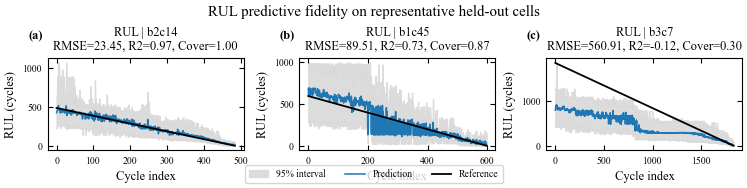

In [152]:
def plot_representative_cells(target: str, pred_df: pd.DataFrame) -> None:
    """Plot worst, median, and best cells for one target."""
    cell_metrics = CELL_METRICS[target]
    representative_cells = select_representative_cells(cell_metrics)
    fig, axes = create_figure(
        layout_type="double",
        aspect_ratio=0.75,
        nrows=1,
        ncols=3,
        sharex=False,
        sharey=False,
    )
    fig.suptitle(
        f"{target} predictive fidelity on representative held-out cells"
    )
    for axis, cell in zip(np.ravel(axes), representative_cells):
        chunk = pred_df[pred_df["cell"] == cell].sort_values("cycle")
        summary = cell_metrics.set_index("cell").loc[cell]
        axis.fill_between(
            chunk["cycle"],
            chunk["y_pred_lo"],
            chunk["y_pred_hi"],
            color="0.85",
            alpha=0.9,
            label=f"{int(NOMINAL_CONFIDENCE_LEVEL * 100)}% interval",
        )
        axis.plot(
            chunk["cycle"],
            chunk["y_pred"],
            color="tab:blue",
            linewidth=1.1,
            label="Prediction",
        )
        axis.plot(
            chunk["cycle"],
            chunk["y_true"],
            color="black",
            linewidth=1.3,
            label="Reference",
        )
        axis.set_title(
            (
                f"{target} | {cell}\nRMSE={summary['rmse']:.2f}, "
                f"R2={summary['r2']:.2f}, Cover={summary['coverage']:.2f}"
            )
        )
        axis.set_xlabel("Cycle index")
        if target == "SOH":
            axis.set_ylabel("SOH (%)")
        else:
            axis.set_ylabel("RUL (cycles)")
    handles, labels = np.ravel(axes)[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=3, frameon=True)
    add_panel_labels(axes, posy=1.3)
    save_figure(fig, f"results_representative_cells_{target.lower()}")
    plt.show()


plot_representative_cells("SOH", TARGET_BUNDLES["SOH"]["predictions"])
plot_representative_cells("RUL", TARGET_BUNDLES["RUL"]["predictions"])

Saved /Users/clarafarias/code/severson_features_soh_rul/paper/overleaf_project/results_all_cells_grid_soh


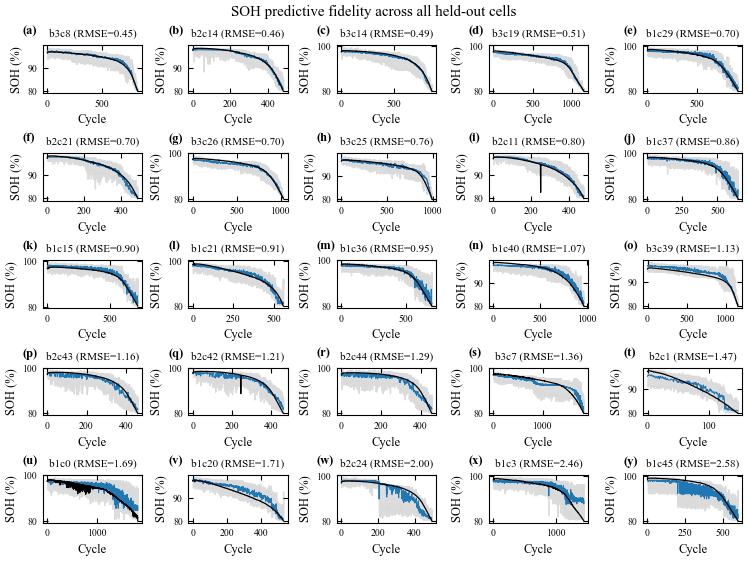

Saved /Users/clarafarias/code/severson_features_soh_rul/paper/overleaf_project/results_all_cells_grid_rul


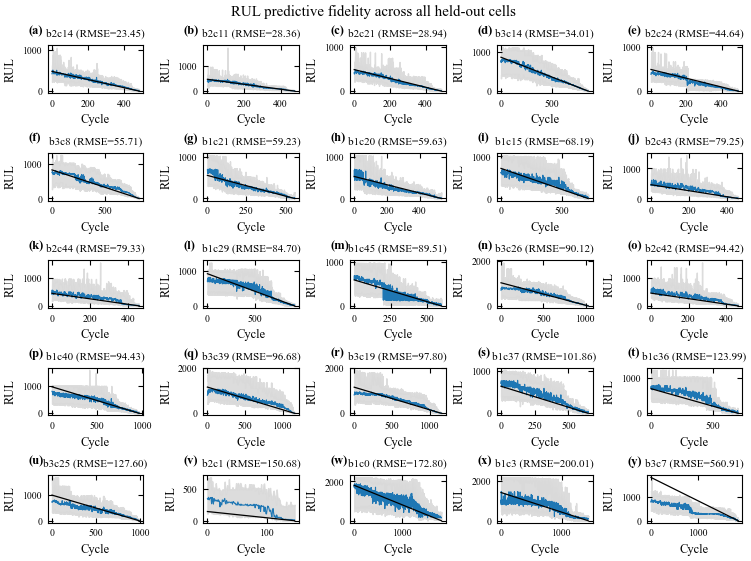

In [153]:
def plot_all_cells_grid(target: str, pred_df: pd.DataFrame) -> None:
    """Plot all test cells on a 5x5 grid for appendix-style inspection."""
    cell_metrics = CELL_METRICS[target]
    ordered_cells = cell_metrics["cell"].tolist()
    fig, axes = create_figure(
        layout_type="double",
        aspect_ratio=0.75,
        nrows=5,
        ncols=5,
        sharex=False,
        sharey=False,
    )
    fig.suptitle(f"{target} predictive fidelity across all held-out cells")
    flat_axes = np.ravel(axes)
    for axis, cell in zip(flat_axes, ordered_cells):
        chunk = pred_df[pred_df["cell"] == cell].sort_values("cycle")
        summary = cell_metrics.set_index("cell").loc[cell]
        axis.fill_between(
            chunk["cycle"],
            chunk["y_pred_lo"],
            chunk["y_pred_hi"],
            color="0.85",
            alpha=0.9,
        )
        axis.plot(
            chunk["cycle"], chunk["y_pred"], color="tab:blue", linewidth=0.8
        )
        axis.plot(
            chunk["cycle"], chunk["y_true"], color="black", linewidth=0.9
        )
        axis.set_title(
            f"{cell} (RMSE={summary['rmse']:.2f})",
            fontsize=8,
        )
        if target == "SOH":
            axis.set_ylabel("SOH (%)")
        else:
            axis.set_ylabel("RUL")
        axis.set_xlabel("Cycle")
    add_panel_labels(axes, posx=-0.2, posy=1.4)
    save_figure(fig, f"results_all_cells_grid_{target.lower()}")
    plt.show()


plot_all_cells_grid("SOH", TARGET_BUNDLES["SOH"]["predictions"])
plot_all_cells_grid("RUL", TARGET_BUNDLES["RUL"]["predictions"])

Saved /Users/clarafarias/code/severson_features_soh_rul/paper/overleaf_project/results_cell_metric_distributions


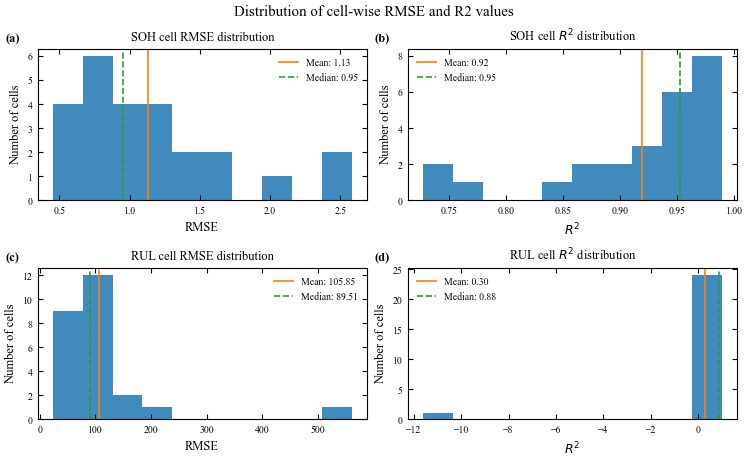

In [154]:
def plot_cell_metric_distributions() -> None:
    """Plot RMSE and R2 distributions across held-out cells."""
    fig, axes = create_figure(
        layout_type="double",
        nrows=2,
        ncols=2,
    )
    fig.suptitle("Distribution of cell-wise RMSE and R2 values")
    plot_specs = [
        ("SOH", "rmse", "SOH cell RMSE distribution", "RMSE"),
        ("SOH", "r2", "SOH cell $R^2$ distribution", "$R^2$"),
        ("RUL", "rmse", "RUL cell RMSE distribution", "RMSE"),
        ("RUL", "r2", "RUL cell $R^2$ distribution", "$R^2$"),
    ]
    for axis, (target, metric, title, xlabel) in zip(
        np.ravel(axes), plot_specs
    ):
        values = CELL_METRICS[target][metric]
        axis.hist(values, color="tab:blue", alpha=0.85)
        axis.axvline(
            values.mean(),
            color="tab:orange",
            linewidth=1.2,
            label=f"Mean: {values.mean():.2f}",
        )
        axis.axvline(
            values.median(),
            color="tab:green",
            linewidth=1.2,
            linestyle="--",
            label=f"Median: {values.median():.2f}",
        )
        axis.set_title(title)
        axis.set_xlabel(xlabel)
        axis.set_ylabel("Number of cells")
        axis.legend(loc="best")
    add_panel_labels(axes)
    save_figure(fig, "results_cell_metric_distributions")
    plt.show()


plot_cell_metric_distributions()

The representative-cell plots show that SOH predictions remain visually well
aligned over most degradation trajectories, while RUL exhibits more severe
failures on a few high-life cells. This is consistent with the reviewer
concern that long-lived cells are underrepresented and therefore harder to
extrapolate.

### Parity Plots

**Methodology.** The parity view collapses all held-out samples into a single
true-versus-predicted scatter. The diagonal line marks ideal agreement.

Saved /Users/clarafarias/code/severson_features_soh_rul/paper/overleaf_project/results_parity_analysis


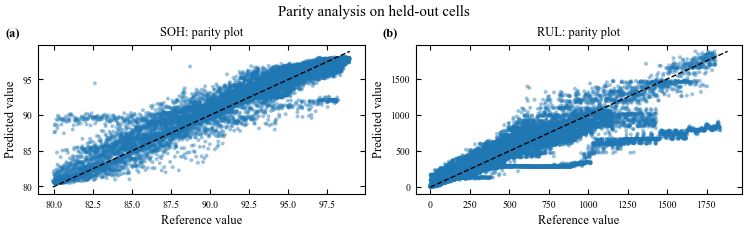

In [155]:
fig, axes = create_figure(
    layout_type="double",
    nrows=1,
    ncols=2,
)
fig.suptitle("Parity analysis on held-out cells")
for axis, (target, bundle) in zip(np.ravel(axes), TARGET_BUNDLES.items()):
    pred_df = bundle["predictions"]
    axis.scatter(
        pred_df["y_true"],
        pred_df["y_pred"],
        color="tab:blue",
        s=8,
        alpha=0.45,
        edgecolors="none",
    )
    min_value = min(pred_df["y_true"].min(), pred_df["y_pred"].min())
    max_value = max(pred_df["y_true"].max(), pred_df["y_pred"].max())
    axis.plot(
        [min_value, max_value],
        [min_value, max_value],
        linestyle="--",
        color="black",
        linewidth=1,
    )
    axis.set_title(f"{target}: parity plot")
    axis.set_xlabel("Reference value")
    axis.set_ylabel("Predicted value")
add_panel_labels(axes)
save_figure(fig, "results_parity_analysis")
plt.show()

## Manuscript Table 2: Cell-Level Heterogeneity

**Methodology.** Reviewer comments explicitly asked whether the largest
deviations are concentrated in unusual cells. The tables below summarize the
hardest and easiest held-out cells for each target using RMSE, coverage, and
average interval width.

In [156]:
for target, metrics in CELL_METRICS.items():
    display(Markdown(f"### {target}: hardest held-out cells"))
    display(metrics.head(5))
    display(Markdown(f"### {target}: easiest held-out cells"))
    display(metrics.sort_values("rmse", ascending=True).head(5))

### SOH: hardest held-out cells

,target,cell,n_samples,rmse,r2,coverage,mean_interval_width,median_interval_width,life_proxy
0,SOH,b3c8,827,0.452975,0.984366,0.995163,4.974936,4.881826,97.155855
1,SOH,b2c14,484,0.456887,0.989243,0.979339,4.112499,4.212430,98.443918
2,SOH,b3c14,857,0.492468,0.985224,0.995333,4.788108,4.497012,97.976745
3,SOH,b3c19,1154,0.513163,0.985186,0.987868,3.621430,3.073269,97.627245
4,SOH,b1c29,915,0.698142,0.977125,0.989071,4.378090,3.867263,98.527536


### SOH: easiest held-out cells

,target,cell,n_samples,rmse,r2,coverage,mean_interval_width,median_interval_width,life_proxy
0,SOH,b3c8,827,0.452975,0.984366,0.995163,4.974936,4.881826,97.155855
1,SOH,b2c14,484,0.456887,0.989243,0.979339,4.112499,4.212430,98.443918
2,SOH,b3c14,857,0.492468,0.985224,0.995333,4.788108,4.497012,97.976745
3,SOH,b3c19,1154,0.513163,0.985186,0.987868,3.621430,3.073269,97.627245
4,SOH,b1c29,915,0.698142,0.977125,0.989071,4.378090,3.867263,98.527536


### RUL: hardest held-out cells

,target,cell,n_samples,rmse,r2,coverage,mean_interval_width,median_interval_width,life_proxy
0,RUL,b2c14,484,23.454634,0.971819,0.997934,262.962603,267.95,483.0
1,RUL,b2c11,477,28.363691,0.957570,1.000000,275.049266,290.10,476.0
2,RUL,b2c21,489,28.938479,0.957974,1.000000,274.103067,277.10,488.0
3,RUL,b3c14,857,34.008733,0.981103,0.998833,473.363011,533.60,856.0
4,RUL,b2c24,495,44.635652,0.902425,0.975758,244.874545,240.30,494.0


### RUL: easiest held-out cells

,target,cell,n_samples,rmse,r2,coverage,mean_interval_width,median_interval_width,life_proxy
0,RUL,b2c14,484,23.454634,0.971819,0.997934,262.962603,267.95,483.0
1,RUL,b2c11,477,28.363691,0.957570,1.000000,275.049266,290.10,476.0
2,RUL,b2c21,489,28.938479,0.957974,1.000000,274.103067,277.10,488.0
3,RUL,b3c14,857,34.008733,0.981103,0.998833,473.363011,533.60,856.0
4,RUL,b2c24,495,44.635652,0.902425,0.975758,244.874545,240.30,494.0


For SOH, even the worst cells remain within a relatively narrow absolute
error range. For RUL, the spread is much larger and the hardest cell is a
genuine outlier with both high error and low coverage, which supports a
manuscript discussion on the difficulty of extrapolating long cycle life from
a finite, imbalanced training set.

### Uncertainty Diagnostics

**Methodology.** A useful uncertainty model should widen its intervals when
predictions become less reliable. The plots below therefore compare absolute
error against interval width at the sample level and summarize coverage at the
cell level.

Saved /Users/clarafarias/code/severson_features_soh_rul/paper/overleaf_project/results_width_vs_error


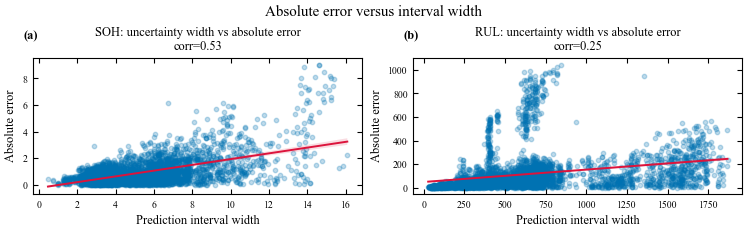

In [157]:
fig, axes = create_figure(
    layout_type="double",
    nrows=1,
    ncols=2,
)
fig.suptitle("Absolute error versus interval width")
for axis, (target, bundle) in zip(np.ravel(axes), TARGET_BUNDLES.items()):
    pred_df = bundle["predictions"]
    sampled = pred_df.sample(
        n=min(4000, pred_df.shape[0]),
        random_state=42,
    )
    sns.regplot(
        data=sampled,
        x="interval_width",
        y="abs_error",
        # lowess=True,
        scatter_kws={"s": 10, "alpha": 0.25},
        line_kws={"color": "crimson", "linewidth": 1.4},
        ax=axis,
    )
    axis.set_title(
        (
            f"{target}: uncertainty width vs absolute error\n"
            f"corr={pred_df['interval_width'].corr(pred_df['abs_error']):.2f}"
        )
    )
    axis.set_xlabel("Prediction interval width")
    axis.set_ylabel("Absolute error")
add_panel_labels(axes, posx=-0.03, posy=1.2)
save_figure(fig, "results_width_vs_error")
plt.show()

Saved /Users/clarafarias/code/severson_features_soh_rul/paper/overleaf_project/results_cell_coverage


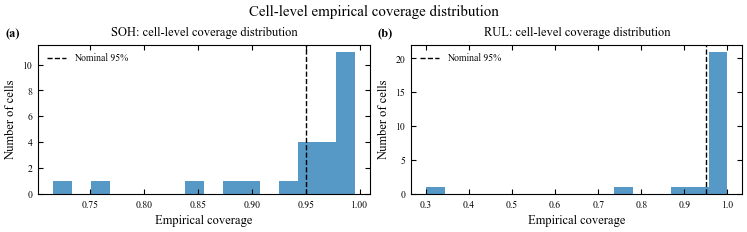

In [158]:
fig, axes = create_figure(
    layout_type="double",
    nrows=1,
    ncols=2,
)
fig.suptitle("Cell-level empirical coverage distribution")
for axis, (target, metrics) in zip(np.ravel(axes), CELL_METRICS.items()):
    sns.histplot(
        metrics["coverage"],
        bins=16,
        color="tab:blue",
        ax=axis,
        edgecolor=None,
    )
    axis.axvline(
        NOMINAL_CONFIDENCE_LEVEL,
        color="black",
        linestyle="--",
        label=f"Nominal {NOMINAL_CONFIDENCE_LEVEL:.0%}",
    )
    axis.set_title(f"{target}: cell-level coverage distribution")
    axis.set_xlabel("Empirical coverage")
    axis.set_ylabel("Number of cells")
    axis.legend()
add_panel_labels(axes)
save_figure(fig, "results_cell_coverage")
plt.show()

The positive width-error relationship, combined with the cell-level coverage
distributions, supports the claim that the uncertainty intervals are
meaningful rather than cosmetic. Coverage is not uniform across all cells,
which is expected because conformal guarantees are marginal rather than
per-cell; still, the aggregate behavior remains close to the intended level.

### RUL Error as a Function of Cycle Life

**Methodology.** Reviewer feedback highlighted unusually long-lived cells as a
challenging regime. The plot below checks that directly by comparing each
test-cell RMSE against its maximum observed RUL, which serves here as a proxy
for cycle life.

Saved /Users/clarafarias/code/severson_features_soh_rul/paper/overleaf_project/results_rul_error_vs_cycle_life


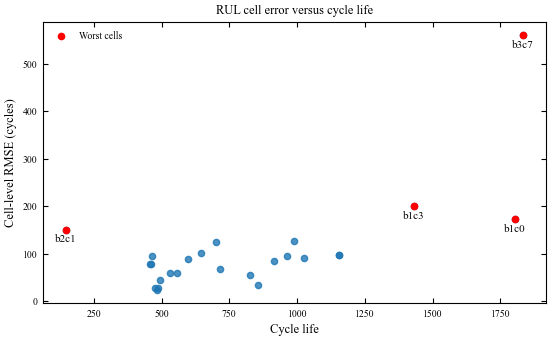

In [159]:
fig, ax = create_figure(layout_type="one_and_a_half")
rul_cell_metrics = CELL_METRICS["RUL"].copy()
ax.scatter(
    rul_cell_metrics["life_proxy"],
    rul_cell_metrics["rmse"],
    color="tab:blue",
    alpha=0.8,
)
tail_size = 4
for _, row in rul_cell_metrics.tail(tail_size).iterrows():
    l1 = ax.scatter(
        row["life_proxy"],
        row["rmse"],
        color="red",
        label="Worst cells",
    )
    ax.annotate(
        row["cell"],
        (row["life_proxy"], row["rmse"]),
        xytext=(-8, -9),
        textcoords="offset points",
        fontsize=8,
    )
ax.set_title("RUL cell error versus cycle life")
ax.set_xlabel("Cycle life")
ax.set_ylabel("Cell-level RMSE (cycles)")
ax.legend(handles=[l1])
save_figure(fig, "results_rul_error_vs_cycle_life")
plt.show()

In [160]:
print(
    "RUL cells above 1200 cycles and their RMSE values:\n",
    rul_cell_metrics.loc[
        rul_cell_metrics["life_proxy"] > 1200,
        [
            "cell",
            "life_proxy",
            "rmse",
            "coverage",
            "mean_interval_width",
        ],
    ]
    .sort_values("rmse", ascending=False)
    .to_string(index=False),
)

RUL cells above 1200 cycles and their RMSE values:
 cell  life_proxy       rmse  coverage  mean_interval_width
b3c7      1834.0 560.909347  0.300272           511.922725
b1c3      1431.0 200.008811  0.987430          1265.191760
b1c0      1805.0 172.799681  0.946814          1223.789529


This figure can be used to support a careful manuscript statement: the model
is effective over most of the test set, but the error profile is not uniform.
The largest RUL failures occur on exceptionally long-lived cells, which is
consistent with an imbalance-driven extrapolation problem rather than a
uniform model deficiency.

## Feature Ranking and Physical Interpretation

**Methodology.** The ranking stage is based on permutation predictions
generated under grouped cross-validation. Features are ranked using the
composite score already saved by the pipeline, which combines the impact on
predictive error and interval width. The table below should be interpreted as
a compact diagnostic of useful waveform descriptors, not as a causal proof of
electrochemical mechanisms.

Saved /Users/clarafarias/code/severson_features_soh_rul/paper/overleaf_project/results_feature_ranking


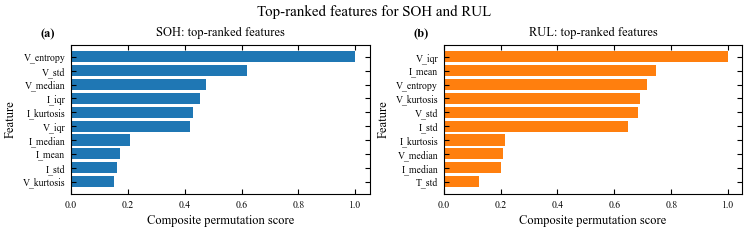

In [161]:
fig, axes = create_figure(
    layout_type="double",
    nrows=1,
    ncols=2,
)
fig.suptitle("Top-ranked features for SOH and RUL")
for axis, (target, bundle) in zip(np.ravel(axes), TARGET_BUNDLES.items()):
    ranking = bundle["ranking"].head(10).sort_values("composite_score")
    axis.barh(
        ranking["feature"],
        ranking["composite_score"],
        color="tab:blue" if target == "SOH" else "tab:orange",
    )
    axis.set_title(f"{target}: top-ranked features")
    axis.set_xlabel("Composite permutation score")
    axis.set_ylabel("Feature")
add_panel_labels(axes)
save_figure(fig, "results_feature_ranking")
plt.show()

In [162]:
for target, bundle in TARGET_BUNDLES.items():
    display(Markdown(f"### {target}: top feature interpretation table"))
    display(build_feature_interpretation_table(bundle["ranking"], top_n=8))

### SOH: top feature interpretation table

,feature,composite_score,mechanistic_interpretation
0,V_entropy,1.000000,Voltage-profile irregularity; a proxy for wave...
1,V_std,0.619595,Voltage spread within the diagnostic cycle; co...
2,V_median,0.475555,Central tendency of the voltage trace; sensiti...
3,I_iqr,0.453038,Robust current spread; helps distinguish proto...
4,I_kurtosis,0.430207,Current transients and tail behavior; useful w...
5,V_iqr,0.419590,Robust voltage dispersion; captures broadening...
6,I_median,0.207894,Central current tendency; another compact summ...
7,I_mean,0.171756,Average current level seen by the model under ...


### RUL: top feature interpretation table

,feature,composite_score,mechanistic_interpretation
0,V_iqr,1.000000,Robust voltage dispersion; captures broadening...
1,I_mean,0.745997,Average current level seen by the model under ...
2,V_entropy,0.714863,Voltage-profile irregularity; a proxy for wave...
3,V_kurtosis,0.690022,Tail-heaviness of the voltage distribution; ca...
4,V_std,0.682280,Voltage spread within the diagnostic cycle; co...
5,I_std,0.649422,Current variability during the cycle; reflects...
6,I_kurtosis,0.216542,Current transients and tail behavior; useful w...
7,V_median,0.210086,Central tendency of the voltage trace; sensiti...


The ranking outputs suggest that voltage-distribution descriptors dominate the
SOH task, whereas RUL depends on a broader mix of voltage and current
statistics. This supports a practical interpretation for the paper: SOH can
be inferred from compact summaries of the instantaneous waveform shape,
whereas RUL needs richer descriptors because it encodes the full remaining
degradation trajectory.

## Compact Subset Selection via the Top-k Sweep

**Methodology.** The top-k sweep evaluates progressively larger feature
subsets using the ranking order above. A subset is considered feasible if its
RMSE and interval width remain within the configured tolerance relative to the
full-feature baseline. This directly addresses the reviewer request to explain
how compact subsets compare with the full 16-feature representation.

Saved /Users/clarafarias/code/severson_features_soh_rul/paper/overleaf_project/results_topk_sweep


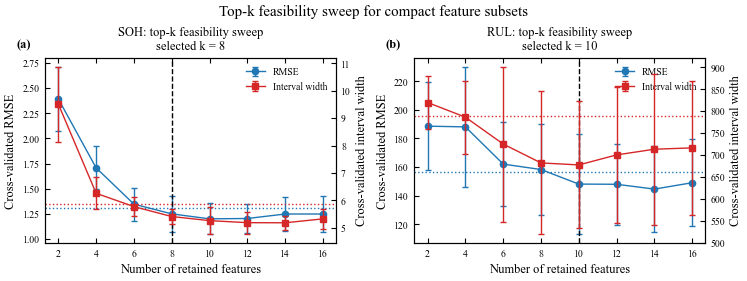

In [163]:
def build_topk_summary_table(
    target: str,
    topk_df: pd.DataFrame,
    selection: dict[str, object],
) -> pd.DataFrame:
    """Summarize compactness trade-offs for the selected top-k subset."""
    baseline_row = topk_df.sort_values("k").iloc[-1]
    selected_row = topk_df.loc[topk_df["k"] == selection["selected_k"]].iloc[0]
    return pd.DataFrame(
        [
            {
                "target": target,
                "setting": "Full feature set",
                "k": int(baseline_row["k"]),
                "rmse_mean": float(baseline_row["rmse_mean"]),
                "interval_width_mean": float(
                    baseline_row["interval_width_mean"]
                ),
                "is_feasible": bool(baseline_row["is_feasible"]),
                "features": baseline_row["selected_features"],
            },
            {
                "target": target,
                "setting": "Selected compact subset",
                "k": int(selected_row["k"]),
                "rmse_mean": float(selected_row["rmse_mean"]),
                "interval_width_mean": float(
                    selected_row["interval_width_mean"]
                ),
                "is_feasible": bool(selected_row["is_feasible"]),
                "features": format_feature_subset(
                    selection["selected_features"]
                ),
            },
        ]
    )


fig, axes = create_figure(
    layout_type="double",
    aspect_ratio=0.75,
    nrows=1,
    ncols=2,
)
fig.suptitle("Top-k feasibility sweep for compact feature subsets")
for axis, (target, bundle) in zip(np.ravel(axes), TARGET_BUNDLES.items()):
    topk_df = bundle["topk_sweep"]
    selection = bundle["topk_selection"]
    width_axis = axis.twinx()
    line_rmse = axis.errorbar(
        topk_df["k"],
        topk_df["rmse_mean"],
        yerr=topk_df["rmse_std"],
        marker="o",
        color="tab:blue",
        label="RMSE",
    )
    line_width = width_axis.errorbar(
        topk_df["k"],
        topk_df["interval_width_mean"],
        yerr=topk_df["interval_width_std"],
        marker="s",
        color="tab:red",
        label="Interval width",
    )
    axis.axvline(
        selection["selected_k"],
        color="black",
        linestyle="--",
        linewidth=1.0,
    )
    axis.axhline(
        selection["rmse_threshold"],
        color="tab:blue",
        linestyle=":",
        linewidth=1.0,
    )
    width_axis.axhline(
        selection["width_threshold"],
        color="tab:red",
        linestyle=":",
        linewidth=1.0,
    )
    axis.set_title(
        (
            f"{target}: top-k feasibility sweep\n"
            f"selected k = {selection['selected_k']}"
        )
    )
    axis.set_xlabel("Number of retained features")
    axis.set_ylabel("Cross-validated RMSE")
    width_axis.set_ylabel("Cross-validated interval width")
    width_axis.grid(False)
    axis.legend(
        [line_rmse, line_width],
        ["RMSE", "Interval width"],
        loc="upper right",
    )
add_panel_labels(axes)
save_figure(fig, "results_topk_sweep")
plt.show()

In [164]:
topk_tables = []
for target, bundle in TARGET_BUNDLES.items():
    topk_tables.append(
        build_topk_summary_table(
            target,
            bundle["topk_sweep"],
            bundle["topk_selection"],
        )
    )
topk_summary_table = pd.concat(topk_tables, ignore_index=True)
display(topk_summary_table)

,target,setting,k,rmse_mean,interval_width_mean,is_feasible,features
0,SOH,Full feature set,16,1.249365,5.321464,True,"V_entropy,V_std,V_median,I_iqr,I_kurtosis,V_iq..."
1,SOH,Selected compact subset,8,1.250740,5.406261,True,"V_entropy, V_std, V_median, I_iqr, I_kurtosis,..."
2,RUL,Full feature set,16,149.039066,716.140220,True,"V_iqr,I_mean,V_entropy,V_kurtosis,V_std,I_std,..."
3,RUL,Selected compact subset,10,148.077882,677.223742,True,"V_iqr, I_mean, V_entropy, V_kurtosis, V_std, I..."


In [165]:
for target, bundle in TARGET_BUNDLES.items():
    selection = bundle["topk_selection"]
    print(
        (
            f"{target}: selected {selection['selected_k']} features -> "
            f"{format_feature_subset(selection['selected_features'])}"
        )
    )

SOH: selected 8 features -> V_entropy, V_std, V_median, I_iqr, I_kurtosis, V_iqr, I_median, I_mean
RUL: selected 10 features -> V_iqr, I_mean, V_entropy, V_kurtosis, V_std, I_std, I_kurtosis, V_median, I_median, T_std


These compact subsets can be discussed in the manuscript as a practical
deployment result. The top-k sweep does not merely rank features; it shows
that a materially smaller subset can preserve most of the predictive value,
which strengthens the claim that the method is lightweight rather than only
accurate.

## Protocol Robustness Under Strict Leave-One-Protocol-Out Validation

**Methodology.** Reviewer comments also asked whether models trained on some
fast-charge protocols can generalize to cells run under different protocols.
The LOPO analysis operationalizes that question directly: each protocol is
held out in turn, the model is fit on the remaining protocols, and the
resulting errors are summarized by held-out protocol.

Saved /Users/clarafarias/code/severson_features_soh_rul/paper/overleaf_project/results_protocol_lopo


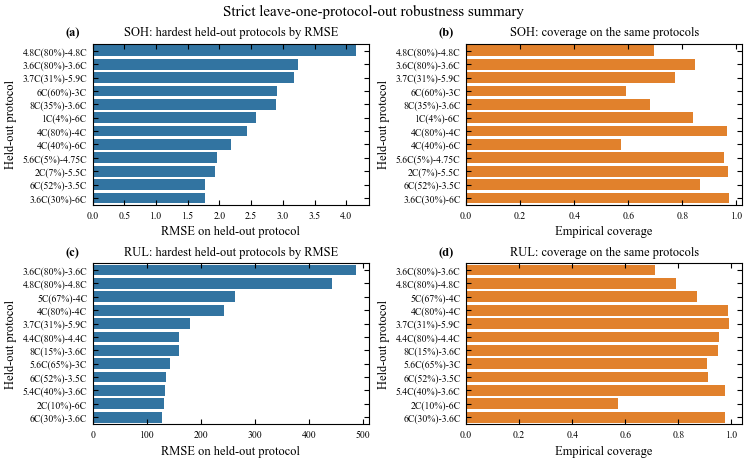

In [166]:
fig, axes = create_figure(
    layout_type="double",
    nrows=2,
    ncols=2,
)
fig.suptitle("Strict leave-one-protocol-out robustness summary")
for row_idx, target in enumerate(["SOH", "RUL"]):
    protocol_df = (
        PROTOCOL_METRICS[target]
        .tail(12)
        .sort_values("rmse", ascending=False)
        .copy()
    )
    rmse_axis = axes[row_idx, 0]
    coverage_axis = axes[row_idx, 1]
    sns.barplot(
        data=protocol_df,
        x="rmse",
        y="protocol",
        color="tab:blue",
        ax=rmse_axis,
    )
    sns.barplot(
        data=protocol_df,
        x="coverage",
        y="protocol",
        color="tab:orange",
        ax=coverage_axis,
    )
    rmse_axis.set_title(f"{target}: hardest held-out protocols by RMSE")
    rmse_axis.set_xlabel("RMSE on held-out protocol")
    rmse_axis.set_ylabel("Held-out protocol")
    coverage_axis.set_title(f"{target}: coverage on the same protocols")
    coverage_axis.set_xlabel("Empirical coverage")
    coverage_axis.set_ylabel("Held-out protocol")
add_panel_labels(axes)
save_figure(fig, "results_protocol_lopo")
plt.show()

In [167]:
for target, protocol_metrics in PROTOCOL_METRICS.items():
    display(Markdown(f"### {target}: protocol LOPO summary"))
    display(protocol_metrics.head(12))

### SOH: protocol LOPO summary

,target,protocol,n_cells,n_samples,rmse,coverage,mean_interval_width
0,SOH,4C(4%)-4.85C,1,484,0.409142,0.913223,4.348831
1,SOH,5.2C(50%)-4.25C,1,518,0.505429,0.992278,3.875095
2,SOH,5.6C(19%)-4.6C,7,6737,0.524579,0.991688,4.686716
3,SOH,5.6C(47%)-4C,1,464,0.529583,0.993534,4.440507
4,SOH,4.65C(19%)-4.85C,1,489,0.542378,0.920245,4.765535
5,SOH,4.4C(24%)-5C,1,493,0.566936,0.983773,4.828593
6,SOH,5.9C(15%)-4.6C,2,1732,0.570417,0.994226,5.157047
7,SOH,7C(30%)-3.6C,2,1441,0.619837,0.994448,4.799639
8,SOH,5C(67%)-4C,6,6688,0.671900,0.994916,5.364524
9,SOH,6C(50%)-3C,2,1773,0.677894,0.982516,4.551050


### RUL: protocol LOPO summary

,target,protocol,n_cells,n_samples,rmse,coverage,mean_interval_width
0,RUL,4C(31%)-5,1,457,24.901557,0.951860,326.328446
1,RUL,4C(4%)-4.85C,1,484,25.827143,0.923554,272.423140
2,RUL,5.2C(10%)-4.75C,1,481,25.832983,0.910603,240.957173
3,RUL,3.6C(2%)-4.85C,1,479,26.338094,0.899791,240.503967
4,RUL,5.6C(38%)-4.25C,1,478,26.501796,0.945607,286.587866
5,RUL,5.6C(47%)-4C,1,464,27.673201,0.926724,243.803233
6,RUL,2C(2%)-5C,1,438,28.396250,0.952055,249.672831
7,RUL,4.4C(8%)-4.85C,1,501,29.635342,0.946108,246.109980
8,RUL,4.65C(19%)-4.85C,1,489,30.270356,0.952965,243.707975
9,RUL,5.2C(71%)-3C,1,463,32.540422,0.924406,220.222462


The LOPO results are important for the paper because they distinguish
within-protocol interpolation from genuine protocol transfer. Performance is
still useful on many unseen protocols, but the spread in held-out RMSE shows
that protocol identity remains a major source of distribution shift,
especially for RUL. This is a more defensible response to the reviewer than a
generic claim of broad generalization.

## Suggested Manuscript Text Blocks

The snippets below are short draft paragraphs that can be adapted directly
into the Results and Discussion sections.

In [168]:
soh_summary = GLOBAL_SUMMARY.set_index("target").loc["SOH"]
rul_summary = GLOBAL_SUMMARY.set_index("target").loc["RUL"]
display(
    Markdown(
        (
            "### Draft Results Text: Overall performance\n"
            f"The proposed model achieved an SOH test RMSE of "
            f"{soh_summary['rmse']:.2f} with $R^2={soh_summary['r2']:.2f}$, "
            f"while the RUL model achieved an RMSE of {rul_summary['rmse']:.1f} "
            f"cycles with $R^2={rul_summary['r2']:.2f}$. The empirical coverage "
            f"of the conformal intervals remained close to the nominal "
            f"{NOMINAL_CONFIDENCE_LEVEL:.0%} level for both targets "
            f"({soh_summary['empirical_coverage']:.1%} for SOH and "
            f"{rul_summary['empirical_coverage']:.1%} for RUL), indicating that "
            "the uncertainty estimates were not only sample-dependent but also "
            "reasonably calibrated at the aggregate level."
        )
    )
)

### Draft Results Text: Overall performance
The proposed model achieved an SOH test RMSE of 1.31 with $R^2=0.91$, while the RUL model achieved an RMSE of 198.9 cycles with $R^2=0.75$. The empirical coverage of the conformal intervals remained close to the nominal 95% level for both targets (94.1% for SOH and 92.2% for RUL), indicating that the uncertainty estimates were not only sample-dependent but also reasonably calibrated at the aggregate level.

In [169]:
display(
    Markdown(
        (
            "### Draft Results Text: Hard cases and long-lived cells\n"
            "The per-cell analysis shows that SOH errors remain comparatively "
            "stable across held-out cells, whereas RUL exhibits a heavier tail "
            "of difficult cases. In particular, the largest RUL errors are "
            "concentrated in exceptionally long-lived cells, which supports the "
            "interpretation that the main failure mode is extrapolation toward a "
            "sparsely represented high-life regime rather than a uniform loss of "
            "accuracy across the test set."
        )
    )
)

### Draft Results Text: Hard cases and long-lived cells
The per-cell analysis shows that SOH errors remain comparatively stable across held-out cells, whereas RUL exhibits a heavier tail of difficult cases. In particular, the largest RUL errors are concentrated in exceptionally long-lived cells, which supports the interpretation that the main failure mode is extrapolation toward a sparsely represented high-life regime rather than a uniform loss of accuracy across the test set.

In [170]:
display(
    Markdown(
        (
            "### Draft Results Text: Compact subsets and physical interpretation\n"
            "Permutation-based ranking and the subsequent top-k sweep indicate "
            "that the full 16-feature representation is not always necessary. "
            "For SOH, a compact subset dominated by voltage-distribution "
            "descriptors retains most of the predictive value, while RUL "
            "benefits from a broader mixture of voltage and current statistics. "
            "This pattern is consistent with SOH behaving as a near-instantaneous "
            "state descriptor and RUL behaving as a trajectory-level quantity "
            "that depends more strongly on protocol severity and accumulated "
            "stress signatures."
        )
    )
)

### Draft Results Text: Compact subsets and physical interpretation
Permutation-based ranking and the subsequent top-k sweep indicate that the full 16-feature representation is not always necessary. For SOH, a compact subset dominated by voltage-distribution descriptors retains most of the predictive value, while RUL benefits from a broader mixture of voltage and current statistics. This pattern is consistent with SOH behaving as a near-instantaneous state descriptor and RUL behaving as a trajectory-level quantity that depends more strongly on protocol severity and accumulated stress signatures.

## Items Still Outside the Scope of These Artifacts

The current artifact set supports stronger discussion on uncertainty,
protocol robustness, compact subsets, and difficult long-life cells. The
following reviewer requests are still only partially addressed because the
required experiment families are not present in the current results folder:

- explicit temperature ablation,
- partial-cycle / charge-only versus full-cycle comparisons,
- smoothing-window sensitivity,
- cross-chemistry validation,
- throughput-based RUL targets.

If those experiments are run later, this notebook already has the structure
needed to incorporate them as additional sections rather than starting from
scratch.